In [32]:
import pandas as pd
import numpy as np
import heapq
import networkx as nx
import matplotlib.pyplot as plt
from math import radians, cos, sin, sqrt, atan2


In [17]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

In [27]:
def euclidean(lat1, lon1, lat2, lon2):
    return sqrt((lat2 - lat1) ** 2 + (lon2 - lon1) ** 2) * 111  # Approximate conversion to km

In [19]:
def load_cities(file_path):
    df = pd.read_csv(file_path)
    return {row['city']: (row['lat'], row['lng']) for _, row in df.iterrows()}

In [21]:
def build_graph(cities, k=5):
    graph = {city: [] for city in cities}
    for city1 in cities:
        distances = []
        for city2 in cities:
            if city1 != city2:
                dist = haversine(*cities[city1], *cities[city2])
                distances.append((dist, city2))
        distances.sort()
        graph[city1] = distances[:k]
    return graph

In [22]:
def bfs(graph, start, goal):
    queue = [(0, start, [start])]
    visited = set()
    explored = 0
    list_explored = []
    while queue:
        cost, city, path = queue.pop(0)
        explored += 1
        list_explored.append(city)
        if city == goal:
            return path, cost, explored, list_explored
        if city not in visited:
            visited.add(city)
            for dist, neighbor in graph[city]:
                queue.append((cost + dist, neighbor, path + [neighbor]))
    return None

In [23]:
def greedy_best_first(graph, cities, start, goal):
    pq = [(haversine(*cities[start], *cities[goal]), start, [start])]
    visited = set()
    explored = 0
    list_explored = []
    while pq:
        _, city, path = heapq.heappop(pq)
        explored += 1
        list_explored.append(city)
        if city == goal:
            return path, explored, list_explored
        if city not in visited:
            visited.add(city)
            for _, neighbor in graph[city]:
                heapq.heappush(pq, (haversine(*cities[neighbor], *cities[goal]), neighbor, path + [neighbor]))
    return None

In [28]:
def a_star(graph, cities, start, goal, heuristic_type="haversine"):
    def heuristic(city1, city2):
        if heuristic_type == "haversine":
            return haversine(*cities[city1], *cities[city2])
        elif heuristic_type == "euclidean":
            return euclidean(*cities[city1], *cities[city2])
        return 0  # Default case

    pq = [(0, start, [start], 0)]
    visited = set()
    explored = 0
    list_explored = []

    while pq:
        f, city, path, g = heapq.heappop(pq)
        explored += 1
        list_explored.append(city)
        if city == goal:
            return path, g, explored, list_explored
        if city not in visited:
            visited.add(city)
            for cost, neighbor in graph[city]:
                new_g = g + cost
                h = heuristic(neighbor, goal)
                heapq.heappush(pq, (new_g + h, neighbor, path + [neighbor], new_g))
    return None

In [41]:
def draw_path(graph, path, cities, title):
    plt.figure(figsize=(10, 10))

    # Only plot edges and weights for the path:
    if path:
        path_edges = [(path[i], path[i + 1]) for i in range(len(path) - 1)]
        for city1, city2 in path_edges:
            # Find the distance for this edge in the graph
            for dist, neighbor in graph[city1]:
                if neighbor == city2:
                    # Plot the edge
                    plt.plot([cities[city1][1], cities[city2][1]],
                             [cities[city1][0], cities[city2][0]],
                             'r', linewidth=3)
                    # Display the weight
                    plt.text((cities[city1][1] + cities[city2][1]) / 2,
                             (cities[city1][0] + cities[city2][0]) / 2,
                             f'{dist:.1f}', fontsize=8, color='black')
                    break  # Stop searching once the edge is found

    # Plot all cities as points:
    plt.scatter([cities[city][1] for city in cities],
                [cities[city][0] for city in cities],
                c='blue', s=5)

    # Highlight cities in the path:
    if path:
        plt.scatter([cities[city][1] for city in path],
                    [cities[city][0] for city in path],
                    c='yellow', s=50)

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

BFS Path: ['Madrid', 'Leganes', 'Pinto', 'San Martin de la Vega', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Socuellamos', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Cambrils', 'Cunit', 'Castelldefels', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 760.5601222854681 
Explored Cities: 5058 
Explored Order: ['Madrid', 'Leganes', 'Getafe', 'Alcorcon', 'Alcobendas', 'San Fernando de Henares', 'Boadilla del Monte', 'Majadahonda', 'San Sebastian de los Reyes', 'Las Rozas de Madrid', 'Mostoles', 'Getafe', 'Fuenlabrada', 'Alcorcon', 'Mostoles', 'Humanes de Madrid', 'Parla', 'Pinto', 'Madrid', 'Villaviciosa de Odon', 'Boadilla del Monte', 'Leganes', 'Fuenlabrada', 'Pinto', 'Parla', 'Humanes de Madrid', 'Alcorcon', 'Mostoles', 'Madrid', 'Torrejon de la Calzada', 'Valdemoro', 'Mostoles', 'Villaviciosa de Odon', 'Leganes', 'Boadilla del Monte', 'Fuenlabrada', 'Getafe', 'Humanes de Madrid', 'Arroyomolinos', 'Madrid', 'Parla', 'San Sebastian de los

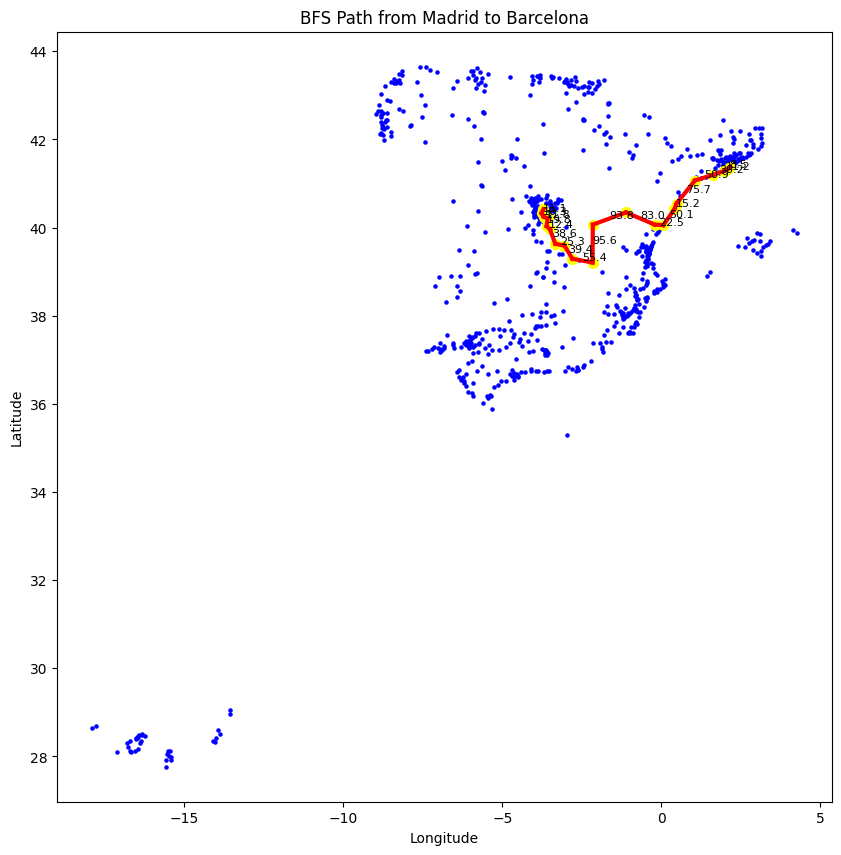

Greedy Best-First Search Path: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Azuqueca de Henares', 'Algete', 'Paracuellos de Jarama', 'Torrejon de Ardoz', 'Vaciamadrid', 'San Martin de la Vega', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'Albacete', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Tortosa', 'Vilaseca de Solcina', 'Cubellas', 'Castelldefels', 'El Prat de Llobregat', 'Barcelona'] 
Explored Cities: 1108 
Explored Order: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Azuqueca de Henares', 'Guadalajara', 'Cabanillas del Campo', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Alovera', 'Azuqueca de Henares', 'Azuqueca de Henares', 'Azuqueca de Henares', 'Meco', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Azuqueca de Henares', 'Meco', 'Meco', 'Meco', 'Meco', 'Villalbilla', 'Alovera', 'Azuqueca de Henares', 'Meco', 'Villalbilla', 'Villalbi

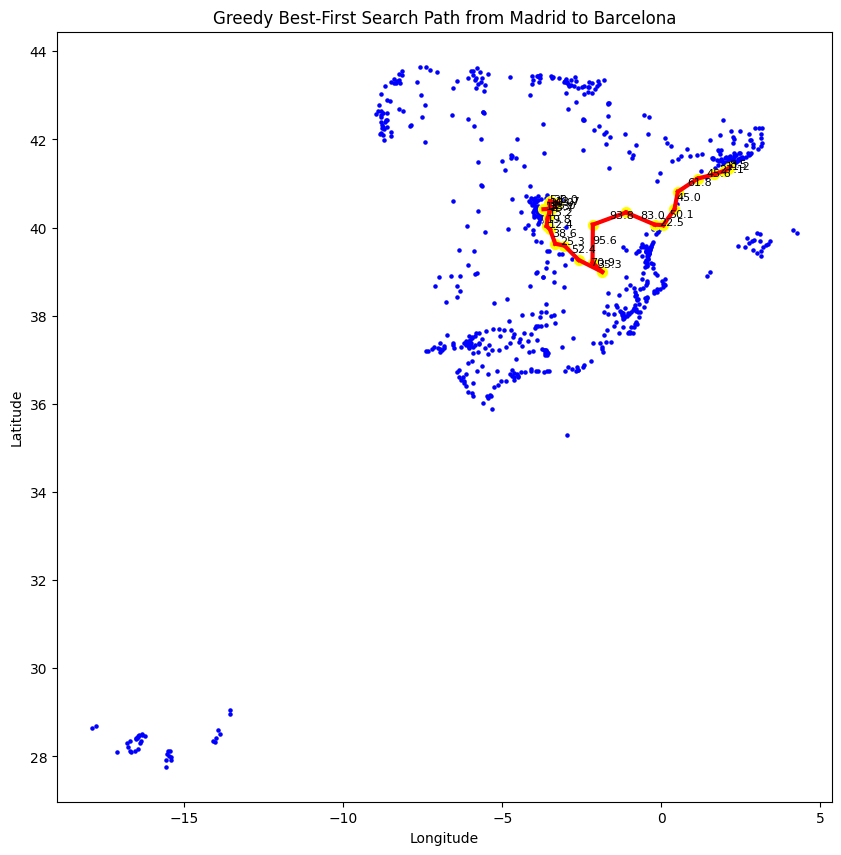

A* Search with Haversine Distance: ['Madrid', 'Getafe', 'Pinto', 'Ciempozuelos', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Salou', 'Cubellas', 'Villanueva y Geltru', 'Gava', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 747.659768029486 
Explored Cities: 1409 
Explored Order: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Torrejon de Ardoz', 'Alcala de Henares', 'Mejorada del Campo', 'Villalbilla', 'Villalbilla', 'Loeches', 'Mejorada del Campo', 'Villalbilla', 'Azuqueca de Henares', 'Guadalajara', 'Alovera', 'Meco', 'Azuqueca de Henares', 'Guadalajara', 'Loeches', 'Daganzo de Arriba', 'Azuqueca de Henares', 'Alcobendas', 'Paracuellos de Jarama', 'Meco', 'Velilla de San Antonio', 'Loeches', 'Daganzo de Arriba', 'Alovera', 'Mejorada del Campo', 'Daganzo de Arriba', 'Meco', 'Mejorada del Campo', 'Daganzo de Arriba', 'Villalbilla', 'Guadalajara', 'San Sebastian de lo

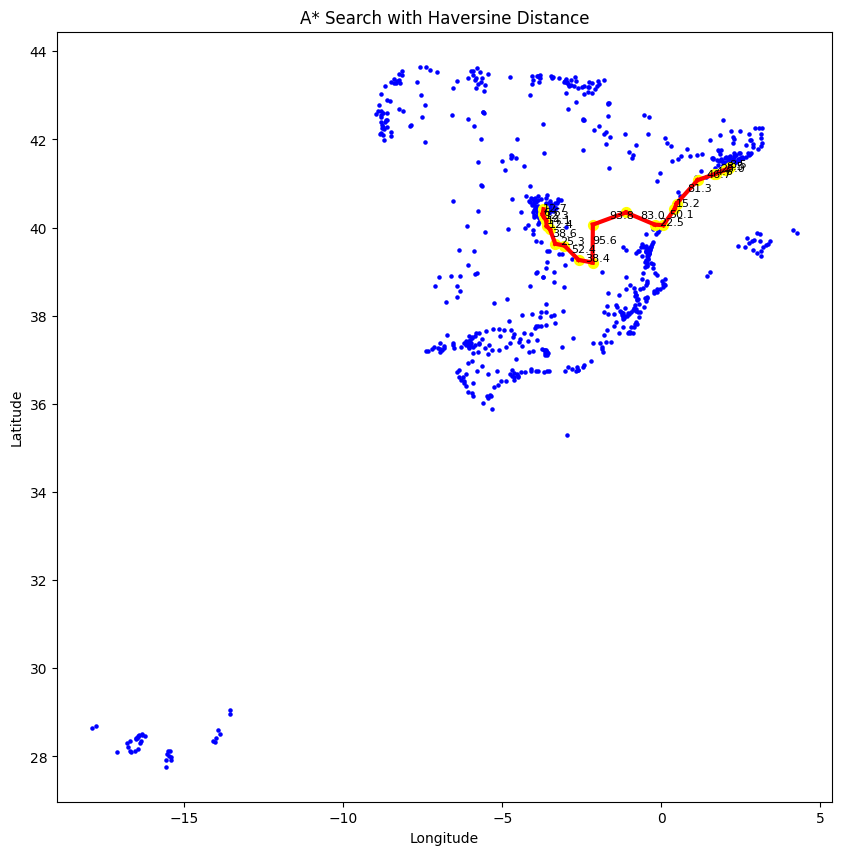

A* Search with Manhattan Distance: ['Madrid', 'Getafe', 'Pinto', 'Ciempozuelos', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Salou', 'Cubellas', 'Villanueva y Geltru', 'Gava', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 747.659768029486 
Explored Cities: 4694 
Explored Order: ['Madrid', 'Leganes', 'Getafe', 'Alcorcon', 'Alcobendas', 'San Fernando de Henares', 'Boadilla del Monte', 'Getafe', 'Majadahonda', 'San Sebastian de los Reyes', 'San Sebastian de los Reyes', 'Leganes', 'Las Rozas de Madrid', 'Mostoles', 'Mostoles', 'Fuenlabrada', 'Alcorcon', 'Alcobendas', 'Las Rozas de Madrid', 'Majadahonda', 'Fuenlabrada', 'Villaviciosa de Odon', 'Pinto', 'Torrejon de Ardoz', 'Leganes', 'Mostoles', 'Alcorcon', 'Villaviciosa de Odon', 'Boadilla del Monte', 'Villaviciosa de Odon', 'Humanes de Madrid', 'Humanes de Madrid', 'Parla', 'Fuenlabrada', 'Parla', 'Pinto', 'Alcorcon', 'Majadahonda

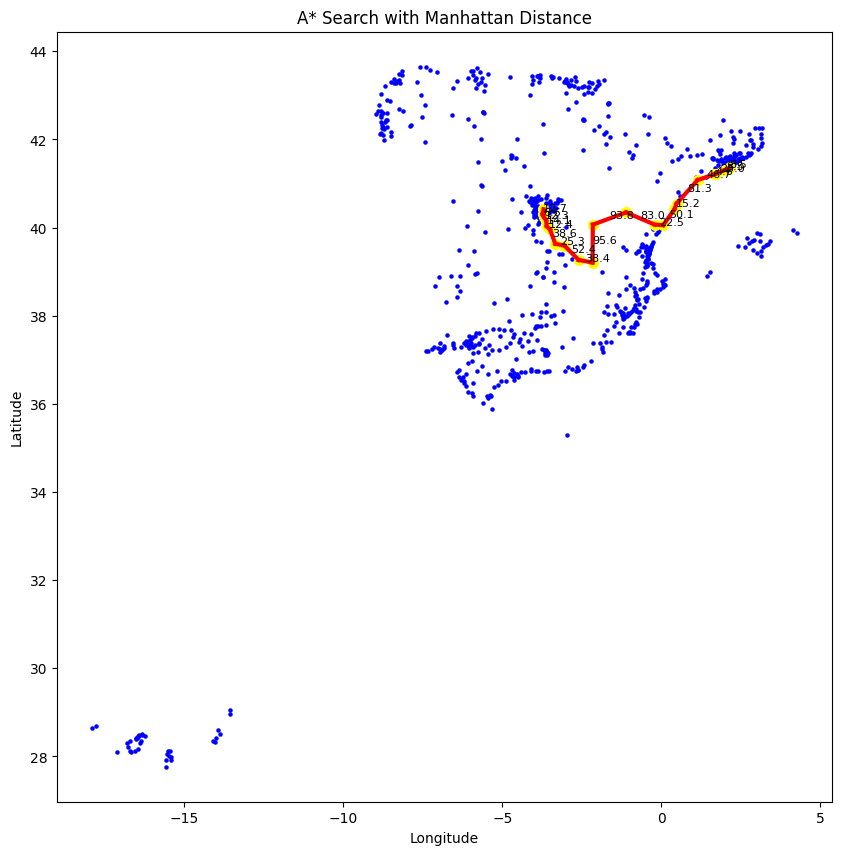

In [42]:
if __name__ == "__main__":
    cities = load_cities("spain_cities.csv")
    graph = build_graph(cities, k=10)
    start, goal = "Madrid", "Barcelona"

    bfs_result = bfs(graph, start, goal)
    print("BFS Path:", bfs_result[0], "\nCost:", bfs_result[1], "\nExplored Cities:", bfs_result[2], "\nExplored Order:", bfs_result[3])
    draw_path(graph, bfs_result[0], cities, "BFS Path from {} to {}".format(start, goal)) # Removed extra argument bfs_result[3]

    gbfs_result = greedy_best_first(graph, cities, start, goal)
    print("Greedy Best-First Search Path:", gbfs_result[0], "\nExplored Cities:", gbfs_result[1], "\nExplored Order:", gbfs_result[2])
    draw_path(graph, gbfs_result[0], cities, "Greedy Best-First Search Path from {} to {}".format(start, goal)) # Removed extra argument gbfs_result[2]

    a_star_result_haversine = a_star(graph, cities, start, goal, heuristic_type="haversine")
    print("A* Search with Haversine Distance:", a_star_result_haversine[0], "\nCost:", a_star_result_haversine[1], "\nExplored Cities:", a_star_result_haversine[2], "\nExplored Order:", a_star_result_haversine[3])
    draw_path(graph, a_star_result_haversine[0], cities, "A* Search with Haversine Distance") # Removed extra argument a_star_result_haversine[3]

    a_star_result_manhattan = a_star(graph, cities, start, goal, heuristic_type="manhattan")
    print("A* Search with Manhattan Distance:", a_star_result_manhattan[0], "\nCost:", a_star_result_manhattan[1], "\nExplored Cities:", a_star_result_manhattan[2], "\nExplored Order:", a_star_result_manhattan[3])
    draw_path(graph, a_star_result_manhattan[0], cities, "A* Search with Manhattan Distance") # Removed extra argument a_star_result_manhattan[3]

In [47]:
def draw_path2(graph, path, cities, title, explored_nodes):
    plt.figure(figsize=(10, 10))
    for city, neighbors in graph.items():
        for dist, neighbor in neighbors:
            plt.plot([cities[city][1], cities[neighbor][1]], [cities[city][0], cities[neighbor][0]], 'gray', alpha=0.5)

    plt.scatter([cities[city][1] for city in cities], [cities[city][0] for city in cities], c='blue', s=10)

    if path:
        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        for city1, city2 in path_edges:
            plt.plot([cities[city1][1], cities[city2][1]], [cities[city1][0], cities[city2][0]], 'r', linewidth=2)
        plt.scatter([cities[city][1] for city in path], [cities[city][0] for city in path], c='yellow', s=50)

    for city in explored_nodes:
        plt.scatter(cities[city][1], cities[city][0], c='green', s=30, alpha=0.6)

    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(title)
    plt.show()

BFS Path: ['Madrid', 'Leganes', 'Pinto', 'San Martin de la Vega', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Socuellamos', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Cambrils', 'Cunit', 'Castelldefels', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 760.5601222854681 
Explored Cities: 5058 
Explored Order: ['Madrid', 'Leganes', 'Getafe', 'Alcorcon', 'Alcobendas', 'San Fernando de Henares', 'Boadilla del Monte', 'Majadahonda', 'San Sebastian de los Reyes', 'Las Rozas de Madrid', 'Mostoles', 'Getafe', 'Fuenlabrada', 'Alcorcon', 'Mostoles', 'Humanes de Madrid', 'Parla', 'Pinto', 'Madrid', 'Villaviciosa de Odon', 'Boadilla del Monte', 'Leganes', 'Fuenlabrada', 'Pinto', 'Parla', 'Humanes de Madrid', 'Alcorcon', 'Mostoles', 'Madrid', 'Torrejon de la Calzada', 'Valdemoro', 'Mostoles', 'Villaviciosa de Odon', 'Leganes', 'Boadilla del Monte', 'Fuenlabrada', 'Getafe', 'Humanes de Madrid', 'Arroyomolinos', 'Madrid', 'Parla', 'San Sebastian de los

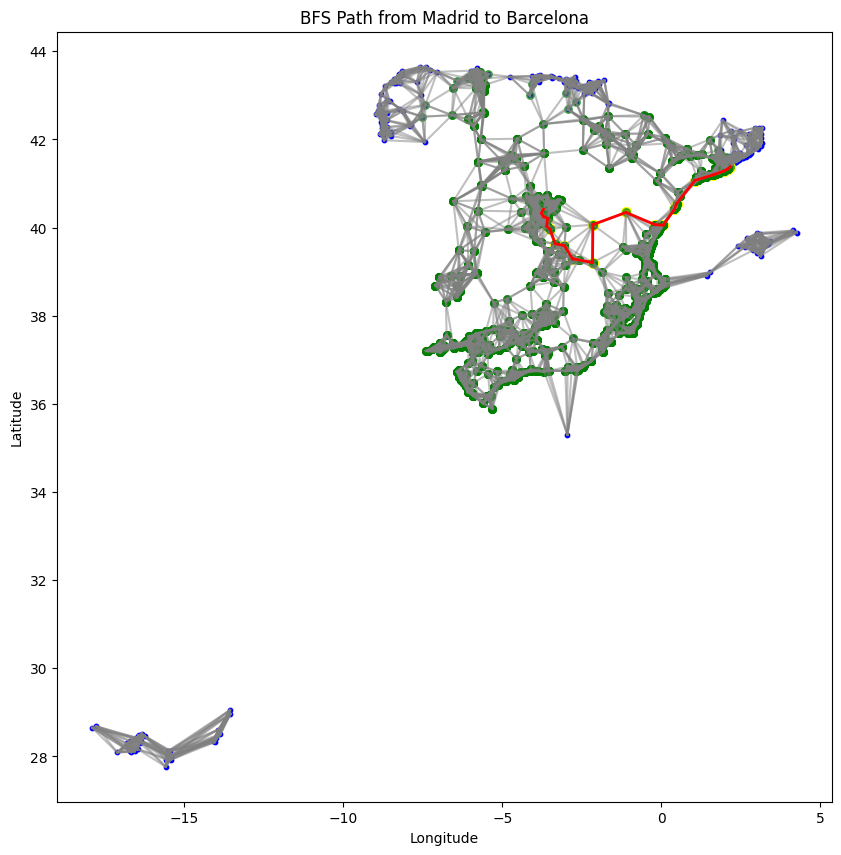

Greedy Best-First Search Path: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Azuqueca de Henares', 'Algete', 'Paracuellos de Jarama', 'Torrejon de Ardoz', 'Vaciamadrid', 'San Martin de la Vega', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'Albacete', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Tortosa', 'Vilaseca de Solcina', 'Cubellas', 'Castelldefels', 'El Prat de Llobregat', 'Barcelona'] 
Explored Cities: 1108 
Explored Order: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Azuqueca de Henares', 'Guadalajara', 'Cabanillas del Campo', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Alovera', 'Azuqueca de Henares', 'Azuqueca de Henares', 'Azuqueca de Henares', 'Meco', 'Guadalajara', 'Cabanillas del Campo', 'Alovera', 'Azuqueca de Henares', 'Meco', 'Meco', 'Meco', 'Meco', 'Villalbilla', 'Alovera', 'Azuqueca de Henares', 'Meco', 'Villalbilla', 'Villalbi

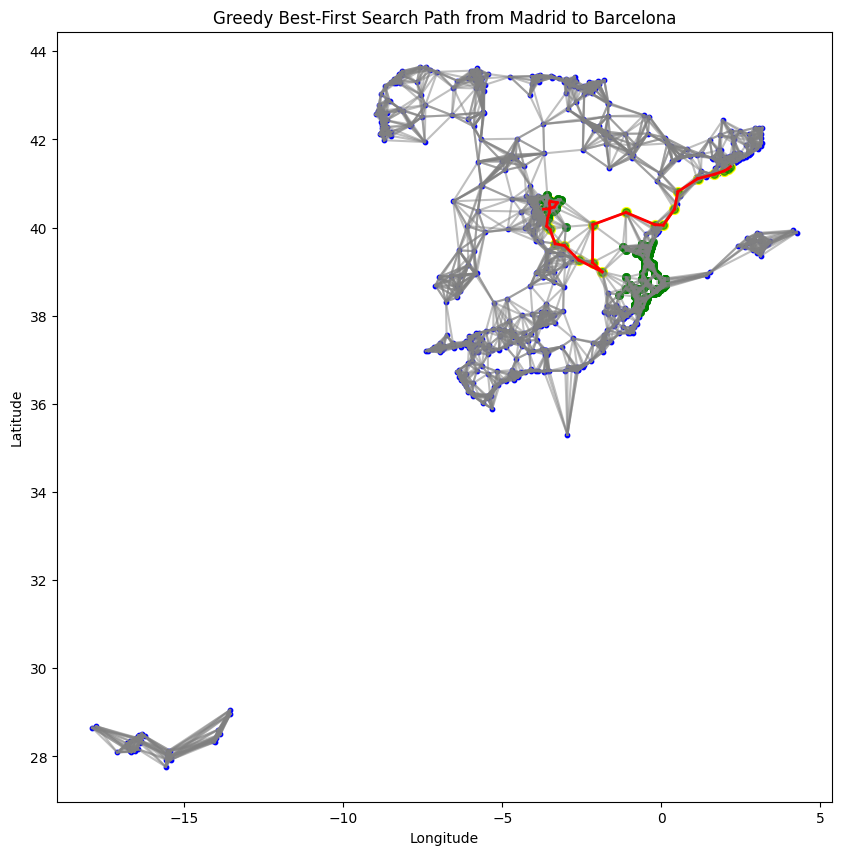

A* Search with Haversine Distance: ['Madrid', 'Getafe', 'Pinto', 'Ciempozuelos', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Salou', 'Cubellas', 'Villanueva y Geltru', 'Gava', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 747.659768029486 
Explored Cities: 1409 
Explored Order: ['Madrid', 'San Fernando de Henares', 'Alcala de Henares', 'Torrejon de Ardoz', 'Alcala de Henares', 'Mejorada del Campo', 'Villalbilla', 'Villalbilla', 'Loeches', 'Mejorada del Campo', 'Villalbilla', 'Azuqueca de Henares', 'Guadalajara', 'Alovera', 'Meco', 'Azuqueca de Henares', 'Guadalajara', 'Loeches', 'Daganzo de Arriba', 'Azuqueca de Henares', 'Alcobendas', 'Paracuellos de Jarama', 'Meco', 'Velilla de San Antonio', 'Loeches', 'Daganzo de Arriba', 'Alovera', 'Mejorada del Campo', 'Daganzo de Arriba', 'Meco', 'Mejorada del Campo', 'Daganzo de Arriba', 'Villalbilla', 'Guadalajara', 'San Sebastian de lo

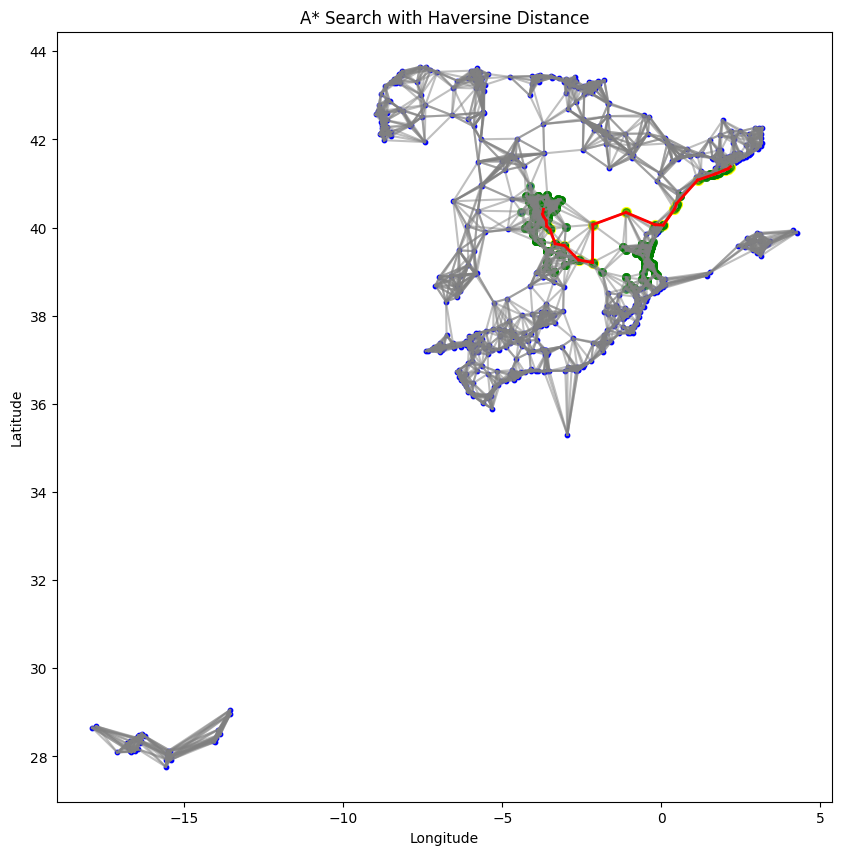

A* Search with Manhattan Distance: ['Madrid', 'Getafe', 'Pinto', 'Ciempozuelos', 'Aranjuez', 'Ocana', 'Villacanas', 'Quintanar de la Orden', 'Villarrobledo', 'La Roda', 'Cuenca', 'Teruel', 'Alcora', 'Benicasim', 'Benicarlo', 'Alcanar', 'Salou', 'Cubellas', 'Villanueva y Geltru', 'Gava', 'El Prat de Llobregat', 'Barcelona'] 
Cost: 747.659768029486 
Explored Cities: 4694 
Explored Order: ['Madrid', 'Leganes', 'Getafe', 'Alcorcon', 'Alcobendas', 'San Fernando de Henares', 'Boadilla del Monte', 'Getafe', 'Majadahonda', 'San Sebastian de los Reyes', 'San Sebastian de los Reyes', 'Leganes', 'Las Rozas de Madrid', 'Mostoles', 'Mostoles', 'Fuenlabrada', 'Alcorcon', 'Alcobendas', 'Las Rozas de Madrid', 'Majadahonda', 'Fuenlabrada', 'Villaviciosa de Odon', 'Pinto', 'Torrejon de Ardoz', 'Leganes', 'Mostoles', 'Alcorcon', 'Villaviciosa de Odon', 'Boadilla del Monte', 'Villaviciosa de Odon', 'Humanes de Madrid', 'Humanes de Madrid', 'Parla', 'Fuenlabrada', 'Parla', 'Pinto', 'Alcorcon', 'Majadahonda

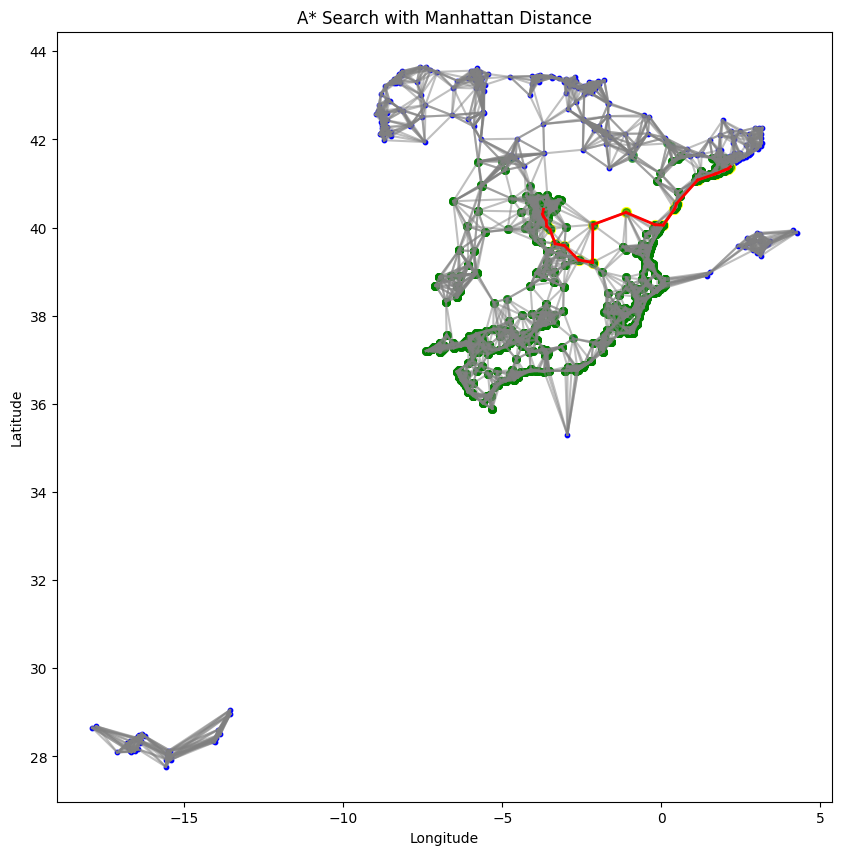

In [48]:
if __name__ == "__main__":
    cities = load_cities("spain_cities.csv")
    graph = build_graph(cities, k=10)
    start, goal = "Madrid", "Barcelona"

    bfs_result = bfs(graph, start, goal)
    print("BFS Path:", bfs_result[0], "\nCost:", bfs_result[1], "\nExplored Cities:", bfs_result[2], "\nExplored Order:", bfs_result[3])
    draw_path2(graph, bfs_result[0], cities, "BFS Path from {} to {}".format(start, goal), bfs_result[3]) # Added explored_nodes argument: bfs_result[3]

    gbfs_result = greedy_best_first(graph, cities, start, goal)
    print("Greedy Best-First Search Path:", gbfs_result[0], "\nExplored Cities:", gbfs_result[1], "\nExplored Order:", gbfs_result[2])
    draw_path2(graph, gbfs_result[0], cities, "Greedy Best-First Search Path from {} to {}".format(start, goal), gbfs_result[2])  # Added explored_nodes argument: gbfs_result[2]

    a_star_result_haversine = a_star(graph, cities, start, goal, heuristic_type="haversine")
    print("A* Search with Haversine Distance:", a_star_result_haversine[0], "\nCost:", a_star_result_haversine[1], "\nExplored Cities:", a_star_result_haversine[2], "\nExplored Order:", a_star_result_haversine[3])
    draw_path2(graph, a_star_result_haversine[0], cities, "A* Search with Haversine Distance", a_star_result_haversine[3]) # Added explored_nodes argument: a_star_result_haversine[3]

    a_star_result_manhattan = a_star(graph, cities, start, goal, heuristic_type="manhattan")
    print("A* Search with Manhattan Distance:", a_star_result_manhattan[0], "\nCost:", a_star_result_manhattan[1], "\nExplored Cities:", a_star_result_manhattan[2], "\nExplored Order:", a_star_result_manhattan[3])
    draw_path2(graph, a_star_result_manhattan[0], cities, "A* Search with Manhattan Distance", a_star_result_manhattan[3]) # Added explored_nodes argument: a_star_result_manhattan[3]